## Seattle Airbnb Market Analysis

In [1]:
import numpy as np
import pandas as pd 
import csv
import os
import re
import matplotlib.pyplot as plt
import datetime
import seaborn as sns


In [2]:
folder_location="./data"

In [3]:
os.walk(folder_location)

<generator object walk at 0x1712cf400>

In [9]:
for base_folder,sub_folders,files in os.walk(folder_location):
    print(base_folder)
    print(sub_folders)
    print(files)

./data
[]
['reviews.csv', 'listings.csv', 'calendar.csv']


In [11]:
files=[os.path.join(folder_location,f) for f in os.listdir(folder_location) if f.endswith(".csv")]

In [13]:

listings_df = pd.read_csv(os.path.join(folder_location, 'listings.csv'))
calendar_df = pd.read_csv(os.path.join(folder_location, 'calendar.csv'))
reviews_df = pd.read_csv(os.path.join(folder_location, 'reviews.csv'))

In [841]:
listings_df['reviews_per_month'] = listings_df['reviews_per_month'].fillna(0)
reviews_df=reviews_df.dropna(subset=['comments'])
calendar_df['price'] = calendar_df['price'].replace(r'[\$,]', '', regex=True).astype(float)
listings_df = listings_df.dropna(axis=1)

listings_df.isna().sum(axis=1)
listings_df['reviews_per_month'] = listings_df['reviews_per_month'].fillna(0)
calendar_df

,listing_id,date,available,price
0,241032,2016-01-04,t,85.0
1,241032,2016-01-05,t,85.0
2,241032,2016-01-06,f,NaN
3,241032,2016-01-07,f,NaN
4,241032,2016-01-08,f,NaN
...,...,...,...,...
1393565,10208623,2016-12-29,f,NaN
1393566,10208623,2016-12-30,f,NaN
1393567,10208623,2016-12-31,f,NaN
1393568,10208623,2017-01-01,f,NaN


In [15]:
print(calendar_df['available'].value_counts())

available
t    934542
f    459028
Name: count, dtype: int64


In [849]:
#1.How many unique listings are there in Seattle?
listings_unique_df=pd.DataFrame(listings_df['id'].drop_duplicates())
listings_unique_df

,id
0,241032
1,953595
2,3308979
3,7421966
4,278830
...,...
3813,8101950
3814,8902327
3815,10267360
3816,9604740


In [845]:
listings_unique_df


,id
0,241032
1,953595
2,3308979
3,7421966
4,278830
...,...
3813,8101950
3814,8902327
3815,10267360
3816,9604740


In [851]:
(listings_df['id'].nunique())

3818

In [853]:
print(listings_df['price'].dtype)

object


In [855]:
listings_df['price'] = listings_df['price'].replace(r'[\$,]', '', regex=True).astype(float)
print(listings_df['price'].head())


0     85.0
1    150.0
2    975.0
3    100.0
4    450.0
Name: price, dtype: float64


In [857]:
print(listings_df['price'].dtype)

float64


In [ ]:
#2.What is the average price of listings in Seattle?

In [859]:
avg_price = listings_df['price'].mean()
avg_price_df = pd.DataFrame([avg_price], columns=['Average Price'])
avg_price_df

,Average Price
0,127.976166


In [861]:
#3.What is the breakdown of listings by room type in Seattle?

room_type_counts = listings_df['room_type'].value_counts()

room_type_counts
room_type_counts_df=room_type_counts.reset_index()
room_type_counts_df.columns=['Room Type','Listing Count']
room_type_counts_df

,Room Type,Listing Count
0,Entire home/apt,2541
1,Private room,1160
2,Shared room,117


In [863]:
listings_df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'description',
       'experiences_offered', 'picture_url', 'host_id', 'host_url', 'street',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city',
       'state', 'market', 'smart_location', 'country_code', 'country',
       'latitude', 'longitude', 'is_location_exact', 'room_type',
       'accommodates', 'bed_type', 'amenities', 'price', 'guests_included',
       'extra_people', 'minimum_nights', 'maximum_nights', 'calendar_updated',
       'has_availability', 'availability_30', 'availability_60',
       'availability_90', 'availability_365', 'calendar_last_scraped',
       'number_of_reviews', 'requires_license', 'jurisdiction_names',
       'instant_bookable', 'cancellation_policy',
       'require_guest_profile_picture', 'require_guest_phone_verification',
       'calculated_host_listings_count', 'reviews_per_month'],
      dtype='object')

In [865]:
#4.Which are the top 5 neighbourhoods in Seattle by number of listings?

top_5_neighbourhoods_df=listings_df['neighbourhood_cleansed'].value_counts().reset_index().head(5)
top_5_neighbourhoods_df.columns = ['Neighbourhood', 'Listings Count']
top_5_neighbourhoods_df

,Neighbourhood,Listings Count
0,Broadway,397
1,Belltown,234
2,Wallingford,167
3,Fremont,158
4,Minor,135


In [867]:
#5.What is the average price for each room type in Seattle?

avg_price_for_each_room_df=pd.DataFrame(listings_df.groupby(['room_type'])['price'].mean().reset_index())
avg_price_for_each_room_df.columns=['Room Type', 'Avg Room Price']
avg_price_for_each_room_df

,Room Type,Avg Room Price
0,Entire home/apt,155.843369
1,Private room,75.044828
2,Shared room,47.547009


In [869]:
#6.Which host has the highest number of listings in Seattle?

host_listing_counts = listings_df.groupby('host_id').size()
host_listing_counts_sorted=host_listing_counts.sort_values(ascending=False)
highest_number_listing_df = host_listing_counts_sorted.reset_index()
highest_number_listing_df.columns = ['Host ID', 'Listings Count']
highest_number_listing_df.head(5)

,Host ID,Listings Count
0,8534462,46
1,4962900,39
2,1243056,37
3,430709,36
4,3074414,34


In [871]:
calendar_df

,listing_id,date,available,price
0,241032,2016-01-04,t,85.0
1,241032,2016-01-05,t,85.0
2,241032,2016-01-06,f,NaN
3,241032,2016-01-07,f,NaN
4,241032,2016-01-08,f,NaN
...,...,...,...,...
1393565,10208623,2016-12-29,f,NaN
1393566,10208623,2016-12-30,f,NaN
1393567,10208623,2016-12-31,f,NaN
1393568,10208623,2017-01-01,f,NaN


In [873]:
#7.What is the date range covered by the calendar data


calendar_df['date'] = pd.to_datetime(calendar_df['date'])
latest_date=calendar_df['date'].max()
earliest_date=calendar_df['date'].min()
calendar_range_df=pd.DataFrame({'Metrics':['Earliest Date','Latest Date'],'value': [earliest_date, latest_date]})
calendar_range_df

,Metrics,value
0,Earliest Date,2016-01-04
1,Latest Date,2017-01-02


In [875]:
#8.What is the average daily price across the entire calendar data?

avg_daily_price=calendar_df['price'].mean()
avg_daily_price_df = pd.DataFrame({
    'Metric': ['Average Daily Price'],
    'Value': [round(avg_daily_price,2)]
})
avg_daily_price_df


,Metric,Value
0,Average Daily Price,137.94


In [879]:
#9.How many days are available vs not available in the calendar data?


calendar_df['available']
days_available=calendar_df['available']=='t'
days_available.sum()
days_not_available=calendar_df['available']=='f'
days_not_available.sum()
calendar_data_df=pd.DataFrame({'Metrics':['Days Available','Days Not Available'],'Value':[days_available.sum(),
                               days_not_available.sum()]})
calendar_data_df

,Metrics,Value
0,Days Available,934542
1,Days Not Available,459028


In [895]:
#10.What is the highest price and lowest price in the calendar data?

price_df=calendar_df['price']
highest_price=price_df.max()
lowest_price=price_df.min()

calen_data_df=pd.DataFrame({'Metrics':['Highest Value','Lowest Value'],'Value':[highest_price,lowest_price]})
calen_data_df

,Metrics,Value
0,Highest Value,1650.0
1,Lowest Value,10.0


In [1206]:
#11.What is the seasonal trend in daily prices — which month has the highest average daily price?



calendar_df['month'] = calendar_df['date'].astype(str).str.split('-').str[1]


monthly_avg_price_df = calendar_df.groupby('month')['price'].mean().reset_index()

monthly_avg_price_df=monthly_avg_price_df.sort_values(by='price',ascending=False)
monthly_avg_price_df.columns=['Month', 'Avg Daily Price']
monthly_avg_price_df

,Month,Avg Daily Price
6,07,152.094150
7,08,150.656594
5,06,147.473137
8,09,143.255949
4,05,139.538183
11,12,137.251835
9,10,137.031939
10,11,135.688738
3,04,135.097005
2,03,128.644488


In [1010]:
#12.Which listing has the highest total revenue based on calendar data?

calendar_df.columns

calendar_df[['listing_id','price']]
highest_total_rev_df=calendar_df.groupby('listing_id')['price'].sum().reset_index()
highest_total_rev_df.sort_values(by='price',ascending=False)
highest_total_rev_df

,listing_id,price
0,3335,37080.0
1,4291,29930.0
2,5682,16669.0
3,6606,33890.0
4,7369,4505.0
...,...,...
3813,10332096,14600.0
3814,10334184,43320.0
3815,10339144,0.0
3816,10339145,86835.0


In [1044]:
#13.What is the total number of reviews in the data?

total_reviews = reviews_df['reviewer_id'].count() #here count will count only non null values 
total_reviews

84831

In [1058]:
#14.What is the date range of reviews — what is the earliest and latest review date?


earliest_review_date=reviews_df['date'].min()
latest_review_date=reviews_df['date'].max()

date_range_df=pd.DataFrame({'Metrics':['Earliest Review Date','Latest Review Date'],'Values':[earliest_review_date,latest_review_date]})
date_range_df

,Metrics,Values
0,Earliest Review Date,2009-06-07
1,Latest Review Date,2016-01-03


In [1147]:
#15.Which listings have the highest number of reviews?


highest_number_review=reviews_df['listing_id'].value_counts().reset_index()





highest_reviews=highest_number_review.max()
highest_review_df=pd.DataFrame(highest_reviews)

In [1149]:
highest_review_df

,0
listing_id,10248139
count,474


In [1169]:
#16.What is the average number of reviews per listing?


total_reviews=reviews_df.shape[0]
total_reviews

unique_listing=reviews_df['listing_id'].nunique()
unique_listing

avg_num_rev_per_listing=total_reviews/unique_listing
avg_num_rev_per_listing
avg_reviews_df = pd.DataFrame({
    'Metric': ['Average Reviews per Listing'],
    'Value': [round(avg_num_rev_per_listing, 2)]
})
avg_reviews_df

,Metric,Value
0,Average Reviews per Listing,26.58


In [1171]:

#17.What is the monthly trend of reviews — how many reviews are posted each month?”
#(Basically: Show how review counts change month by month.)

reviews_df['date'] = pd.to_datetime(reviews_df['date'])
reviews_df['month'] = reviews_df['date'].astype(str).str.split('-').str[1]
monthly_reviews_df = reviews_df.groupby('month').size().reset_index(name='Total Reviews')
monthly_reviews_df = monthly_reviews_df.sort_values(by='month')
monthly_reviews_df

,month,Total Reviews
0,01,2864
1,02,2642
2,03,4157
3,04,4231
4,05,5853
5,06,8542
6,07,10501
7,08,13017
8,09,11675
9,10,8954


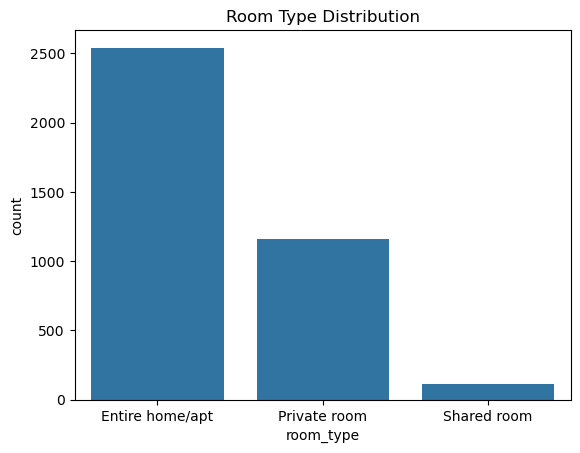

In [1177]:
#Room Type Breakdown

sns.countplot(x='room_type', data=listings_df)
plt.title('Room Type Distribution')
plt.show()

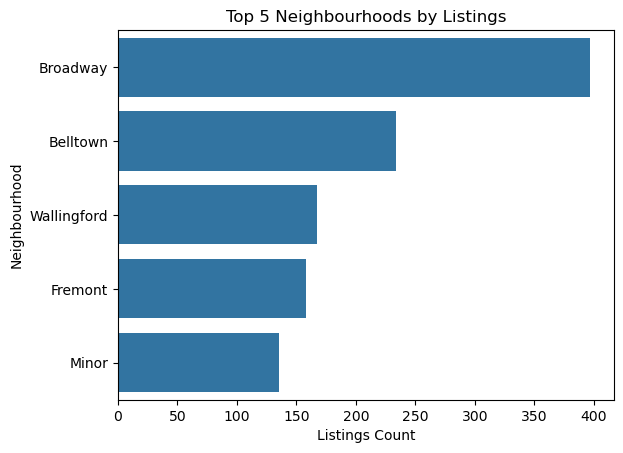

In [1183]:
#Neighbourhood Top 5

sns.barplot(x='Listings Count', y='Neighbourhood', data=top_5_neighbourhoods_df)
plt.title('Top 5 Neighbourhoods by Listings')
plt.show()

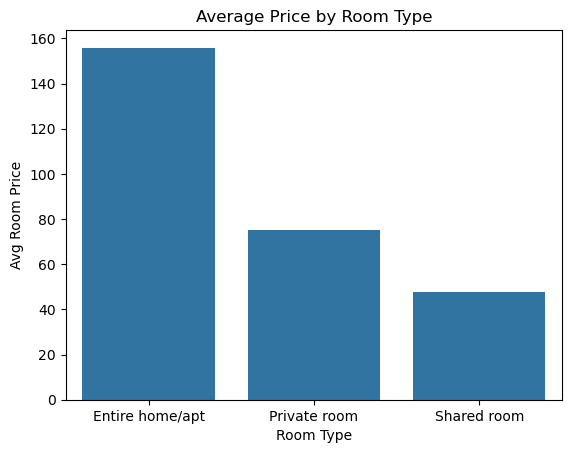

In [1210]:
#Room Type vs Average Price

sns.barplot(x='Room Type', y='Avg Room Price', data=avg_price_for_each_room_df)
plt.title('Average Price by Room Type')
plt.show()

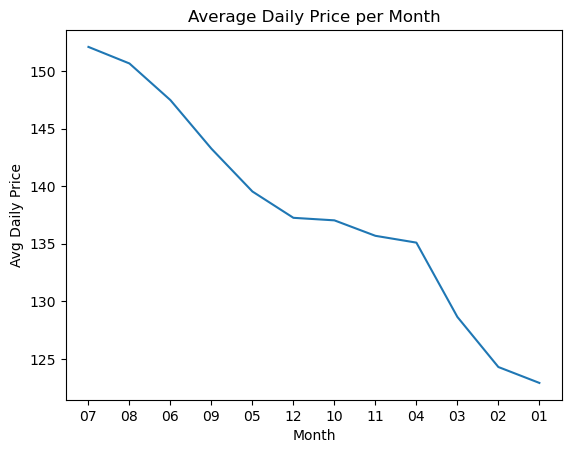

In [1212]:
#Monthly Seasonal Price Trend

sns.lineplot(x='Month', y='Avg Daily Price', data=monthly_avg_price_df)
plt.title('Average Daily Price per Month')
plt.show()


[934542, 459028]


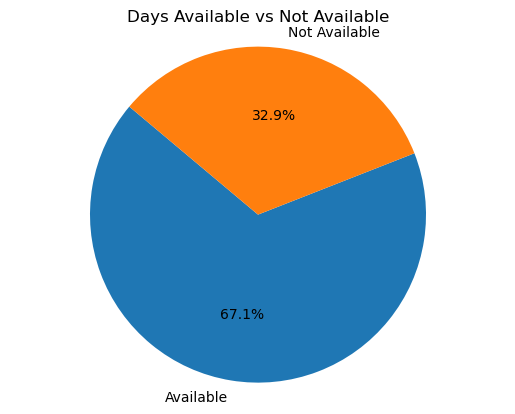

In [1222]:
#Days Available vs Not Available

import matplotlib.pyplot as plt

labels = ['Available', 'Not Available']

# ✅ Ensure these are numbers (not Series!)
days_available = (calendar_df['available'] == 't').sum()
days_not_available = (calendar_df['available'] == 'f').sum()

sizes = [days_available, days_not_available]

print(sizes)  # should be [int, int]

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Days Available vs Not Available')
plt.show()

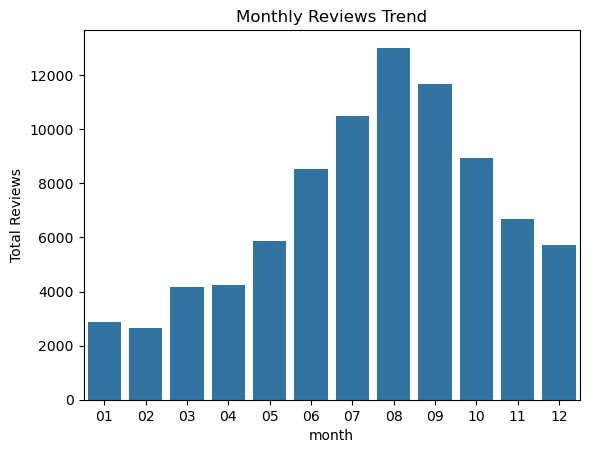

In [1224]:
#.Monthly Review Trend


sns.barplot(x='month', y='Total Reviews', data=monthly_reviews_df)
plt.title('Monthly Reviews Trend')
plt.show()

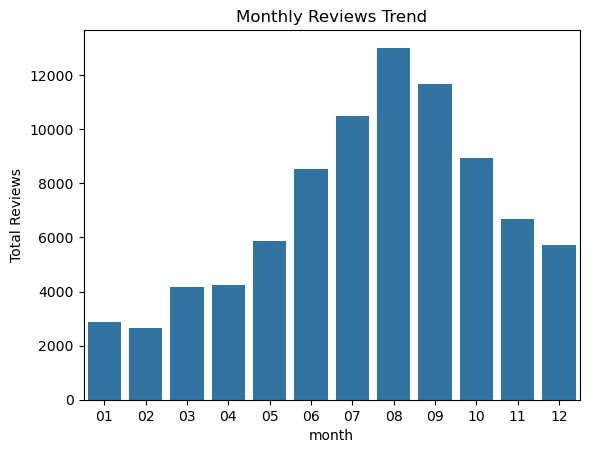

In [1230]:
#.Listings with Highest Reviews

sns.barplot(x='month', y='Total Reviews', data=monthly_reviews_df)
plt.title('Monthly Reviews Trend')
plt.show()